# Optimization Algorithms — TSP & 0/1 Knapsack

| Algorithm | TSP | Knapsack |
|---|---|---|
| **Greedy Deterministic** | Nearest Neighbor (fixed start C0) | Sort by value/weight ratio |
| **Greedy Non-Deterministic** | Nearest Neighbor (best of K random starts) | Random shuffle greedy (best of R trials) |
| **Local Search First Improvement** | 2-opt accept first better swap | Bit-flip accept first better flip |
| **Local Search Best Improvement** | 2-opt accept best swap per iteration | Bit-flip accept best flip per iteration |
| **Simulated Annealing** | 2-opt + Boltzmann acceptance | Bit-flip + Boltzmann acceptance |
| **Genetic Algorithm** | Order Crossover OX + 2-opt mutation | Single-point crossover + bit-flip mutation |

> How to run: Runtime > Run all


## Cell 1 — Imports

In [ ]:
import math, random, copy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SEED = 42
random.seed(SEED)
print("Libraries ready")


Libraries ready


## Cell 2 — Problem Data

In [ ]:
# TSP: 10 cities (x, y)
CITIES = [
    (10, 20), (35, 50), (60, 10), (80, 70),
    (20, 80), (55, 40), (90, 30), (45, 90),
    (15, 55), (70, 55)
]
CITY_NAMES = [f"C{i}" for i in range(len(CITIES))]
N = len(CITIES)

# Knapsack: 8 items (name, weight, value)
ITEMS = [
    ("Laptop",  4, 12),
    ("Camera",  2,  8),
    ("Clothes", 6,  6),
    ("Books",   3,  5),
    ("Tools",   5,  9),
    ("Food",    4,  7),
    ("Shoes",   3,  4),
    ("Phone",   1,  6),
]
CAPACITY = 15
M = len(ITEMS)

print(f"TSP: {N} cities")
print(f"Knapsack: {M} items | capacity = {CAPACITY}")
print()
print(f"{'Item':<12} {'Weight':>7} {'Value':>7} {'V/W':>7}")
print("-" * 36)
for name, w, v in ITEMS:
    print(f"{name:<12} {w:>7} {v:>7} {v/w:>7.2f}")


TSP: 10 cities
Knapsack: 8 items | capacity = 15

Item          Weight   Value     V/W
------------------------------------
Laptop             4      12    3.00
Camera             2       8    4.00
Clothes            6       6    1.00
Books              3       5    1.67
Tools              5       9    1.80
Food               4       7    1.75
Shoes              3       4    1.33
Phone              1       6    6.00


## Cell 3 — Utility Functions

In [ ]:
# ── TSP helpers ──────────────────────────────────────────────────────
def dist(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

def tour_dist(tour):
    return sum(dist(CITIES[tour[i]], CITIES[tour[(i+1)%N]]) for i in range(N))

def two_opt(tour, i, j):
    return tour[:i] + tour[i:j+1][::-1] + tour[j+1:]

def nn_from(start):
    unvis = set(range(N))
    tour  = [start]; unvis.remove(start)
    while unvis:
        c   = tour[-1]
        nxt = min(unvis, key=lambda x: dist(CITIES[c], CITIES[x]))
        tour.append(nxt); unvis.remove(nxt)
    return tour

# ── Knapsack helpers ─────────────────────────────────────────────────
def ks_value(sel):  return sum(ITEMS[i][2] for i in range(M) if sel[i])
def ks_weight(sel): return sum(ITEMS[i][1] for i in range(M) if sel[i])
def ks_ok(sel):     return ks_weight(sel) <= CAPACITY

def random_ks():
    sel = [0]*M
    for i in random.sample(range(M), M):
        if ks_weight(sel) + ITEMS[i][1] <= CAPACITY:
            sel[i] = 1
    return sel

print("Utility functions defined")


Utility functions defined


---
## Cell 4 — Greedy: TSP

**Deterministic:** always start from C0, pick nearest unvisited city.  
**Non-Deterministic:** run nearest-neighbor from K random starts, keep the best result.


In [ ]:
def tsp_greedy_det():
    tour = nn_from(0)
    d    = tour_dist(tour)
    log  = [f"Fixed start C0"]
    for i in range(N):
        a, b = tour[i], tour[(i+1)%N]
        log.append(f"  C{a} -> C{b}  ({dist(CITIES[a], CITIES[b]):.1f})")
    log.append(f"Total distance = {d:.2f}")
    return tour, d, log

def tsp_greedy_nondet(K=6):
    starts = random.sample(range(N), K)
    best_tour, best_d = None, float('inf')
    log = [f"Random starts: {['C'+str(s) for s in starts]}"]
    for s in starts:
        t = nn_from(s); d = tour_dist(t)
        log.append(f"  Start C{s} -> dist = {d:.2f}")
        if d < best_d:
            best_d, best_tour = d, t
    log.append(f"Best dist = {best_d:.2f}  (start C{best_tour[0]})")
    return best_tour, best_d, log

t_gd, d_gd, l_gd = tsp_greedy_det()
t_gn, d_gn, l_gn = tsp_greedy_nondet()

print("=== Greedy Deterministic ===")
for l in l_gd: print(l)
print()
print("=== Greedy Non-Deterministic ===")
for l in l_gn: print(l)


=== Greedy Deterministic ===
Fixed start C0
  C0 -> C8  (35.4)
  C8 -> C1  (20.6)
  C1 -> C5  (22.4)
  C5 -> C9  (21.2)
  C9 -> C3  (18.0)
  C3 -> C7  (40.3)
  C7 -> C4  (26.9)
  C4 -> C2  (80.6)
  C2 -> C6  (36.1)
  C6 -> C0  (80.6)
Total distance = 382.11

=== Greedy Non-Deterministic ===
Random starts: ['C1', 'C0', 'C4', 'C9', 'C6', 'C5']
  Start C1 -> dist = 338.73
  Start C0 -> dist = 382.11
  Start C4 -> dist = 370.90
  Start C9 -> dist = 383.98
  Start C6 -> dist = 349.80
  Start C5 -> dist = 315.09
Best dist = 315.09  (start C5)


---
## Cell 5 — Greedy: Knapsack

**Deterministic:** sort by V/W ratio, take each item if it fits.  
**Non-Deterministic:** shuffle items randomly R times, keep the best feasible selection.


In [ ]:
def ks_greedy_det():
    order = sorted(range(M), key=lambda i: ITEMS[i][2]/ITEMS[i][1], reverse=True)
    sel = [0]*M; wt = 0
    log = ["Sort by V/W ratio:"]
    for i in order:
        nm, w, v = ITEMS[i]
        if wt + w <= CAPACITY:
            sel[i]=1; wt+=w
            log.append(f"  OK  {nm:<10}  V/W={v/w:.2f}  w={w}  total_w={wt}")
        else:
            log.append(f"  NO  {nm:<10}  V/W={v/w:.2f}  w={w}  -- skip")
    log.append(f"Value={ks_value(sel)}  Weight={wt}/{CAPACITY}")
    return sel, ks_value(sel), log

def ks_greedy_nondet(R=30):
    best_sel, best_val = [0]*M, 0
    log = [f"Random shuffle greedy ({R} trials):"]
    for r in range(R):
        order = list(range(M)); random.shuffle(order)
        sel=[0]*M; wt=0
        for i in order:
            if wt+ITEMS[i][1] <= CAPACITY:
                sel[i]=1; wt+=ITEMS[i][1]
        v = ks_value(sel)
        if v > best_val:
            best_val, best_sel = v, sel[:]
            log.append(f"  Trial {r+1:>2}: new best value = {best_val}")
    log.append(f"Best value={best_val}  Weight={ks_weight(best_sel)}/{CAPACITY}")
    return best_sel, best_val, log

s_gd, v_gd, l_gd_ks = ks_greedy_det()
s_gn, v_gn, l_gn_ks = ks_greedy_nondet()

print("=== Greedy Deterministic ===")
for l in l_gd_ks: print(l)
print()
print("=== Greedy Non-Deterministic ===")
for l in l_gn_ks: print(l)


=== Greedy Deterministic ===
Sort by V/W ratio:
  OK  Phone       V/W=6.00  w=1  total_w=1
  OK  Camera      V/W=4.00  w=2  total_w=3
  OK  Laptop      V/W=3.00  w=4  total_w=7
  OK  Tools       V/W=1.80  w=5  total_w=12
  NO  Food        V/W=1.75  w=4  -- skip
  OK  Books       V/W=1.67  w=3  total_w=15
  NO  Shoes       V/W=1.33  w=3  -- skip
  NO  Clothes     V/W=1.00  w=6  -- skip
Value=40  Weight=15/15

=== Greedy Non-Deterministic ===
Random shuffle greedy (30 trials):
  Trial  1: new best value = 29
  Trial  3: new best value = 32
  Trial  6: new best value = 40
Best value=40  Weight=15/15


---
## Cell 6 — Local Search: TSP (2-opt)

Both versions start from the deterministic greedy solution.

**First Improvement:** accept the very first swap that improves distance, restart scan immediately.  
**Best Improvement:** scan all possible swaps, accept only the single best one per iteration.


In [ ]:
def tsp_ls_first(max_iter=2000):
    tour, d, _ = tsp_greedy_det()
    log = [f"Start dist = {d:.2f}"]
    impr = 0
    for _ in range(max_iter):
        found = False
        for i in range(1, N-1):
            if found: break
            for j in range(i+1, N):
                nt = two_opt(tour, i, j)
                nd = tour_dist(nt)
                if nd < d - 1e-10:
                    tour, d = nt, nd; impr += 1
                    log.append(f"  [First] 2-opt({i},{j}) -> {d:.2f}")
                    found = True; break
        if not found: break
    log.append(f"Final dist = {d:.2f}  |  improvements = {impr}")
    return tour, d, log

def tsp_ls_best(max_iter=2000):
    tour, d, _ = tsp_greedy_det()
    log = [f"Start dist = {d:.2f}"]
    impr = 0
    for _ in range(max_iter):
        bd, bi, bj = d, -1, -1
        for i in range(1, N-1):
            for j in range(i+1, N):
                nd = tour_dist(two_opt(tour, i, j))
                if nd < bd - 1e-10:
                    bd, bi, bj = nd, i, j
        if bi == -1: break
        tour = two_opt(tour, bi, bj); d = bd; impr += 1
        log.append(f"  [Best]  2-opt({bi},{bj}) -> {d:.2f}")
    log.append(f"Final dist = {d:.2f}  |  improvements = {impr}")
    return tour, d, log

t_lf, d_lf, l_lf = tsp_ls_first()
t_lb, d_lb, l_lb = tsp_ls_best()

print("=== Local Search First Improvement ===")
for l in l_lf: print(l)
print()
print("=== Local Search Best Improvement ===")
for l in l_lb: print(l)


=== Local Search First Improvement ===
Start dist = 382.11
  [First] 2-opt(2,7) -> 353.54
  [First] 2-opt(6,7) -> 350.92
  [First] 2-opt(6,9) -> 306.01
Final dist = 306.01  |  improvements = 3

=== Local Search Best Improvement ===
Start dist = 382.11
  [Best]  2-opt(3,7) -> 343.08
  [Best]  2-opt(8,9) -> 319.44
  [Best]  2-opt(1,2) -> 315.09
Final dist = 315.09  |  improvements = 3


---
## Cell 7 — Local Search: Knapsack (Bit-flip)

**Neighborhood:** flip one bit (add or remove one item).

**First Improvement:** accept first feasible flip that increases total value.  
**Best Improvement:** try all M flips, accept the one with the highest value gain.


In [ ]:
def ks_ls_first(max_iter=500):
    sel, val, _ = ks_greedy_det()
    log = [f"Start value = {val}"]
    impr = 0
    for _ in range(max_iter):
        found = False
        for i in range(M):
            ns = sel[:]; ns[i] ^= 1
            if ks_ok(ns) and ks_value(ns) > val:
                sel, val = ns, ks_value(ns); impr += 1
                log.append(f"  [First] flip '{ITEMS[i][0]}' -> value = {val}")
                found = True; break
        if not found: break
    log.append(f"Final value = {val}  |  weight = {ks_weight(sel)}/{CAPACITY}  |  improvements = {impr}")
    return sel, val, log

def ks_ls_best(max_iter=500):
    sel, val, _ = ks_greedy_det()
    log = [f"Start value = {val}"]
    impr = 0
    for _ in range(max_iter):
        bv, bi = val, -1
        for i in range(M):
            ns = sel[:]; ns[i] ^= 1
            if ks_ok(ns) and ks_value(ns) > bv:
                bv, bi = ks_value(ns), i
        if bi == -1: break
        sel[bi] ^= 1; val = bv; impr += 1
        log.append(f"  [Best]  flip '{ITEMS[bi][0]}' -> value = {val}")
    log.append(f"Final value = {val}  |  weight = {ks_weight(sel)}/{CAPACITY}  |  improvements = {impr}")
    return sel, val, log

s_lf, v_lf, l_lf_ks = ks_ls_first()
s_lb, v_lb, l_lb_ks = ks_ls_best()

print("=== Local Search First Improvement ===")
for l in l_lf_ks: print(l)
print()
print("=== Local Search Best Improvement ===")
for l in l_lb_ks: print(l)


=== Local Search First Improvement ===
Start value = 40
Final value = 40  |  weight = 15/15  |  improvements = 0

=== Local Search Best Improvement ===
Start value = 40
Final value = 40  |  weight = 15/15  |  improvements = 0


---
## Cell 8 — Simulated Annealing: TSP

At each step a random 2-opt swap is tried.

- If it improves the tour: always accept.
- If it worsens: accept with probability  exp(-delta / T).
- Temperature T decreases by factor alpha each step.

This lets the algorithm escape local optima by occasionally accepting worse solutions.


In [ ]:
def tsp_sa(T0=1000.0, alpha=0.995, Tmin=1e-3):
    tour = list(range(N)); random.shuffle(tour)
    d    = tour_dist(tour)
    best, bd = tour[:], d
    T    = T0
    log  = [f"T0={T0}  alpha={alpha}  Tmin={Tmin}"]
    log.append(f"Initial random dist = {d:.2f}")
    steps = worse_accepted = 0

    while T > Tmin:
        i, j  = sorted(random.sample(range(N), 2))
        nt    = two_opt(tour, i, j)
        nd    = tour_dist(nt)
        delta = nd - d
        if delta < 0 or random.random() < math.exp(-delta / T):
            tour, d = nt, nd
            if delta > 0: worse_accepted += 1
        if d < bd: best, bd = tour[:], d
        T *= alpha; steps += 1

    log.append(f"Steps = {steps}  |  Worse accepted = {worse_accepted}")
    log.append(f"Best dist = {bd:.2f}")
    return best, bd, log

t_sa, d_sa, l_sa = tsp_sa()
print("=== Simulated Annealing TSP ===")
for l in l_sa: print(l)


=== Simulated Annealing TSP ===
T0=1000.0  alpha=0.995  Tmin=0.001
Initial random dist = 522.01
Steps = 2757  |  Worse accepted = 350
Best dist = 306.01


---
## Cell 9 — Simulated Annealing: Knapsack

Same Boltzmann acceptance principle.  
Move = random bit-flip. Infeasible solutions are always rejected.  
delta = new_value - current_value (positive = improvement).


In [ ]:
def ks_sa(T0=300.0, alpha=0.99, Tmin=0.1):
    sel = random_ks(); val = ks_value(sel)
    best, bv = sel[:], val
    T = T0
    log = [f"T0={T0}  alpha={alpha}  Tmin={Tmin}"]
    log.append(f"Initial random value = {val}")
    steps = worse_accepted = 0

    while T > Tmin:
        i  = random.randint(0, M-1)
        ns = sel[:]; ns[i] ^= 1
        if not ks_ok(ns): T *= alpha; continue
        nv    = ks_value(ns)
        delta = nv - val
        if delta > 0 or random.random() < math.exp(delta / T):
            sel, val = ns, nv
            if delta < 0: worse_accepted += 1
        if val > bv: best, bv = sel[:], val
        T *= alpha; steps += 1

    log.append(f"Steps = {steps}  |  Worse accepted = {worse_accepted}")
    log.append(f"Best value = {bv}  |  weight = {ks_weight(best)}/{CAPACITY}")
    return best, bv, log

s_sa, v_sa, l_sa_ks = ks_sa()
print("=== Simulated Annealing Knapsack ===")
for l in l_sa_ks: print(l)


=== Simulated Annealing Knapsack ===
T0=300.0  alpha=0.99  Tmin=0.1
Initial random value = 36
Steps = 541  |  Worse accepted = 140
Best value = 40  |  weight = 15/15


---
## Cell 10 — Genetic Algorithm: TSP

| Component | Method |
|---|---|
| Encoding | Permutation of city indices |
| Initial population | Mix of greedy tours + random permutations |
| Selection | Tournament (k=3) |
| Crossover | Order Crossover (OX) — preserves relative city order |
| Mutation | Random 2-opt swap with probability p_mut |
| Replacement | Elitism — best individual always survives |


In [ ]:
def ox_crossover(p1, p2):
    a, b = sorted(random.sample(range(N), 2))
    child = [-1]*N
    child[a:b+1] = p1[a:b+1]
    fill = [g for g in p2 if g not in child]
    pos  = 0
    for k in range(N):
        if child[k] == -1: child[k] = fill[pos]; pos += 1
    return child

def mutate_tsp(tour, p=0.15):
    if random.random() < p:
        i, j = sorted(random.sample(range(N), 2))
        return two_opt(tour, i, j)
    return tour[:]

def tournament_tsp(pop, fits, k=3):
    cands = random.sample(range(len(pop)), k)
    return pop[min(cands, key=lambda x: fits[x])][:]

def tsp_ga(pop_size=60, generations=400, p_mut=0.15):
    pop  = [nn_from(random.randint(0, N-1)) for _ in range(pop_size//2)]
    pop += [random.sample(range(N), N)      for _ in range(pop_size//2)]
    fits = [tour_dist(t) for t in pop]
    best_tour = pop[fits.index(min(fits))][:]
    best_d    = min(fits)
    log       = [f"Init best dist = {best_d:.2f}"]
    history   = [best_d]

    for gen in range(generations):
        new_pop = [best_tour[:]]
        while len(new_pop) < pop_size:
            p1    = tournament_tsp(pop, fits)
            p2    = tournament_tsp(pop, fits)
            child = ox_crossover(p1, p2)
            child = mutate_tsp(child, p_mut)
            new_pop.append(child)
        pop  = new_pop
        fits = [tour_dist(t) for t in pop]
        gd   = min(fits)
        history.append(gd)
        if gd < best_d:
            best_d = gd
            best_tour = pop[fits.index(gd)][:]
            log.append(f"  Gen {gen+1:>3}: new best dist = {best_d:.2f}")

    log.append(f"Final best dist = {best_d:.2f}")
    return best_tour, best_d, log, history

t_ga, d_ga, l_ga, hist_tsp = tsp_ga()
print("=== Genetic Algorithm TSP ===")
for l in l_ga: print(l)


=== Genetic Algorithm TSP ===
Init best dist = 315.09
Final best dist = 315.09


---
## Cell 11 — Genetic Algorithm: Knapsack

| Component | Method |
|---|---|
| Encoding | Binary string of length M |
| Fitness | Total value if feasible; heavy penalty if overweight |
| Selection | Tournament (k=3) |
| Crossover | Single-point crossover |
| Mutation | Flip each bit with probability p_mut |
| Repair | Remove random items until feasible after crossover/mutation |


In [ ]:
def fitness_ks(sel):
    v = ks_value(sel); w = ks_weight(sel)
    if w > CAPACITY: return -(w - CAPACITY) * 100
    return v

def repair_ks(sel):
    sel = sel[:]
    ones = [i for i in range(M) if sel[i]]; random.shuffle(ones)
    for i in ones:
        if ks_weight(sel) <= CAPACITY: break
        sel[i] = 0
    return sel

def sp_crossover(p1, p2):
    pt = random.randint(1, M-1)
    return p1[:pt] + p2[pt:]

def mutate_ks(sel, p=0.1):
    sel = sel[:]
    for i in range(M):
        if random.random() < p: sel[i] ^= 1
    return repair_ks(sel)

def tournament_ks(pop, fits, k=3):
    cands = random.sample(range(len(pop)), k)
    return pop[max(cands, key=lambda x: fits[x])][:]

def ks_ga(pop_size=60, generations=300, p_mut=0.1):
    pop  = [repair_ks([random.randint(0,1) for _ in range(M)]) for _ in range(pop_size)]
    fits = [fitness_ks(s) for s in pop]
    best_sel = pop[fits.index(max(fits))][:]
    best_v   = max(fits)
    log      = [f"Init best value = {best_v}"]
    history  = [best_v]

    for gen in range(generations):
        new_pop = [best_sel[:]]
        while len(new_pop) < pop_size:
            p1    = tournament_ks(pop, fits)
            p2    = tournament_ks(pop, fits)
            child = sp_crossover(p1, p2)
            child = mutate_ks(child, p_mut)
            new_pop.append(child)
        pop  = new_pop
        fits = [fitness_ks(s) for s in pop]
        gv   = max(fits)
        history.append(gv)
        if gv > best_v:
            best_v   = gv
            best_sel = pop[fits.index(gv)][:]
            log.append(f"  Gen {gen+1:>3}: new best value = {best_v}")

    log.append(f"Final best value = {best_v}  |  weight = {ks_weight(best_sel)}/{CAPACITY}")
    return best_sel, best_v, log, history

s_ga, v_ga, l_ga_ks, hist_ks = ks_ga()
print("=== Genetic Algorithm Knapsack ===")
for l in l_ga_ks: print(l)


=== Genetic Algorithm Knapsack ===
Init best value = 39
  Gen   1: new best value = 40
Final best value = 40  |  weight = 15/15


---
## Cell 12 — TSP: Visualization

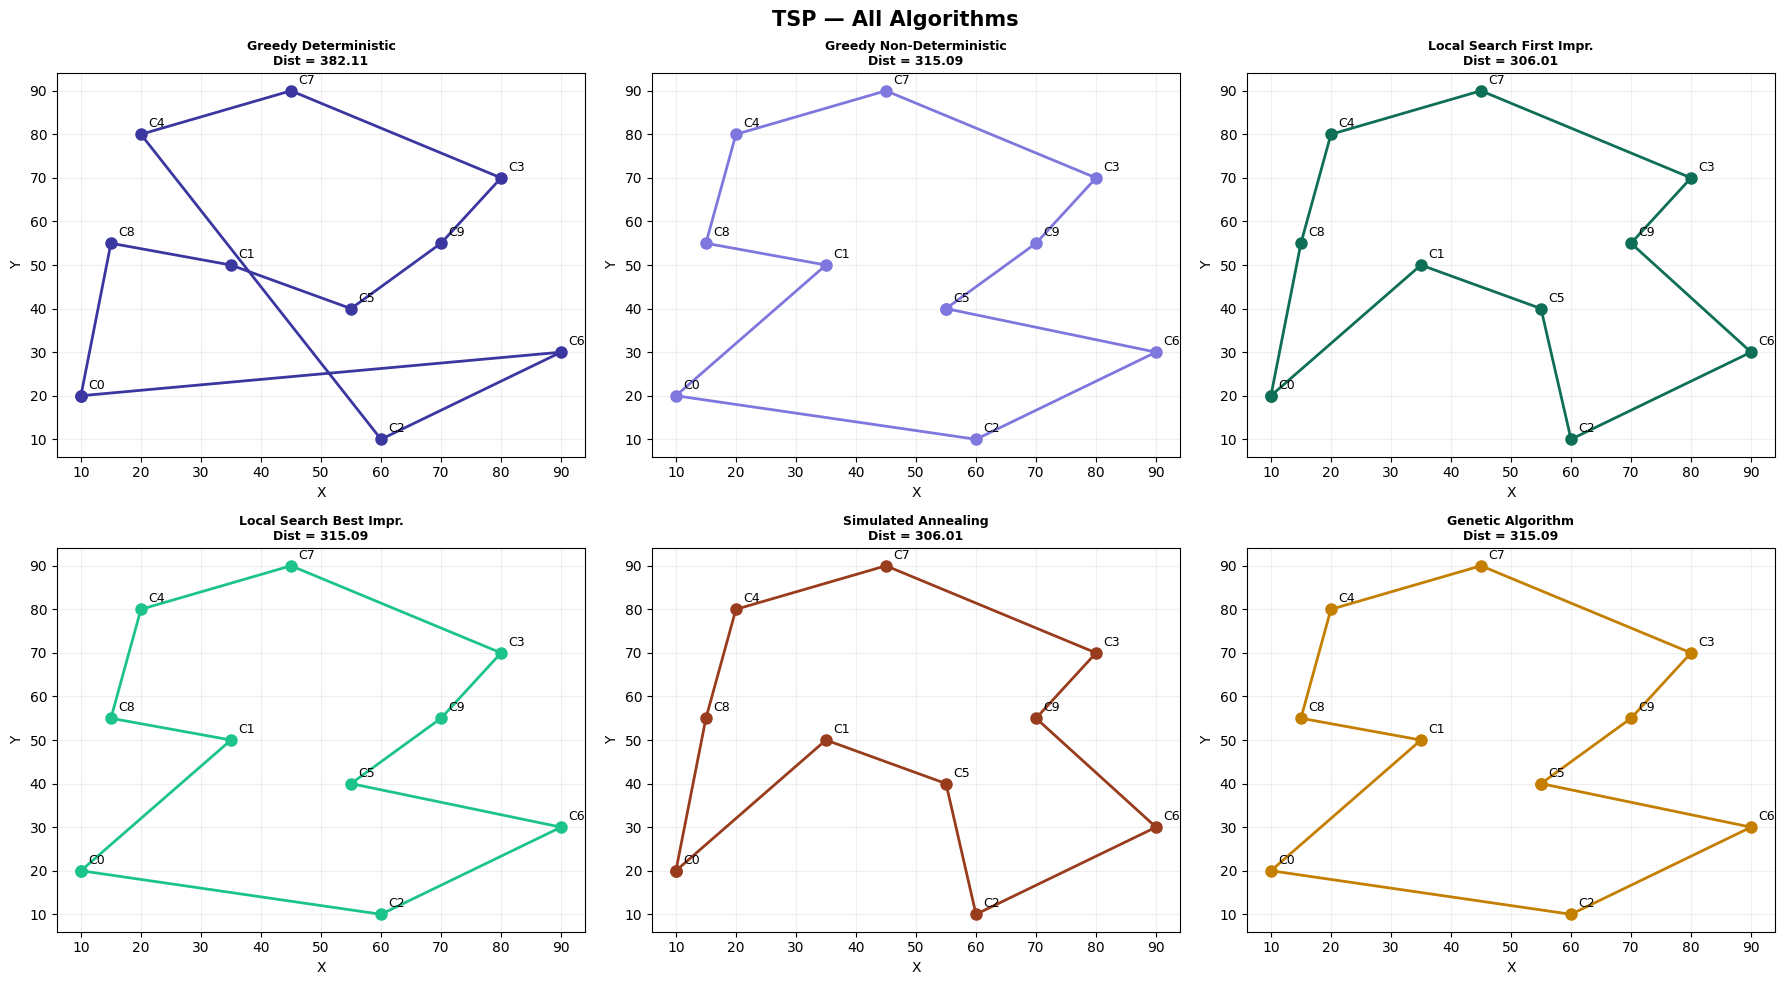

Saved: tsp_all.png


In [ ]:
def draw_tour(ax, tour, title, color, d):
    xs = [CITIES[tour[i%N]][0] for i in range(N+1)]
    ys = [CITIES[tour[i%N]][1] for i in range(N+1)]
    ax.plot(xs, ys, '-o', color=color, markersize=8, linewidth=2)
    for i, (x, y) in enumerate(CITIES):
        ax.annotate(CITY_NAMES[i], (x,y), xytext=(5,5),
                    textcoords='offset points', fontsize=9)
    ax.set_title(f"{title}\nDist = {d:.2f}", fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.2); ax.set_xlabel("X"); ax.set_ylabel("Y")

TSP_ALL = [
    (tsp_greedy_det,    "Greedy Deterministic",         '#3B37A0'),
    (tsp_greedy_nondet, "Greedy Non-Deterministic",     '#7F77DD'),
    (tsp_ls_first,      "Local Search First Impr.",     '#0F6E56'),
    (tsp_ls_best,       "Local Search Best Impr.",      '#1DC48A'),
    (tsp_sa,            "Simulated Annealing",           '#993C1D'),
    (tsp_ga,            "Genetic Algorithm",             '#C47F00'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("TSP — All Algorithms", fontsize=15, fontweight='bold')

for idx, (fn, title, color) in enumerate(TSP_ALL):
    ax  = axes[idx//3][idx%3]
    res = fn()
    draw_tour(ax, res[0], title, color, res[1])

plt.tight_layout()
plt.savefig("tsp_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tsp_all.png")


## Cell 13 — Knapsack: Visualization

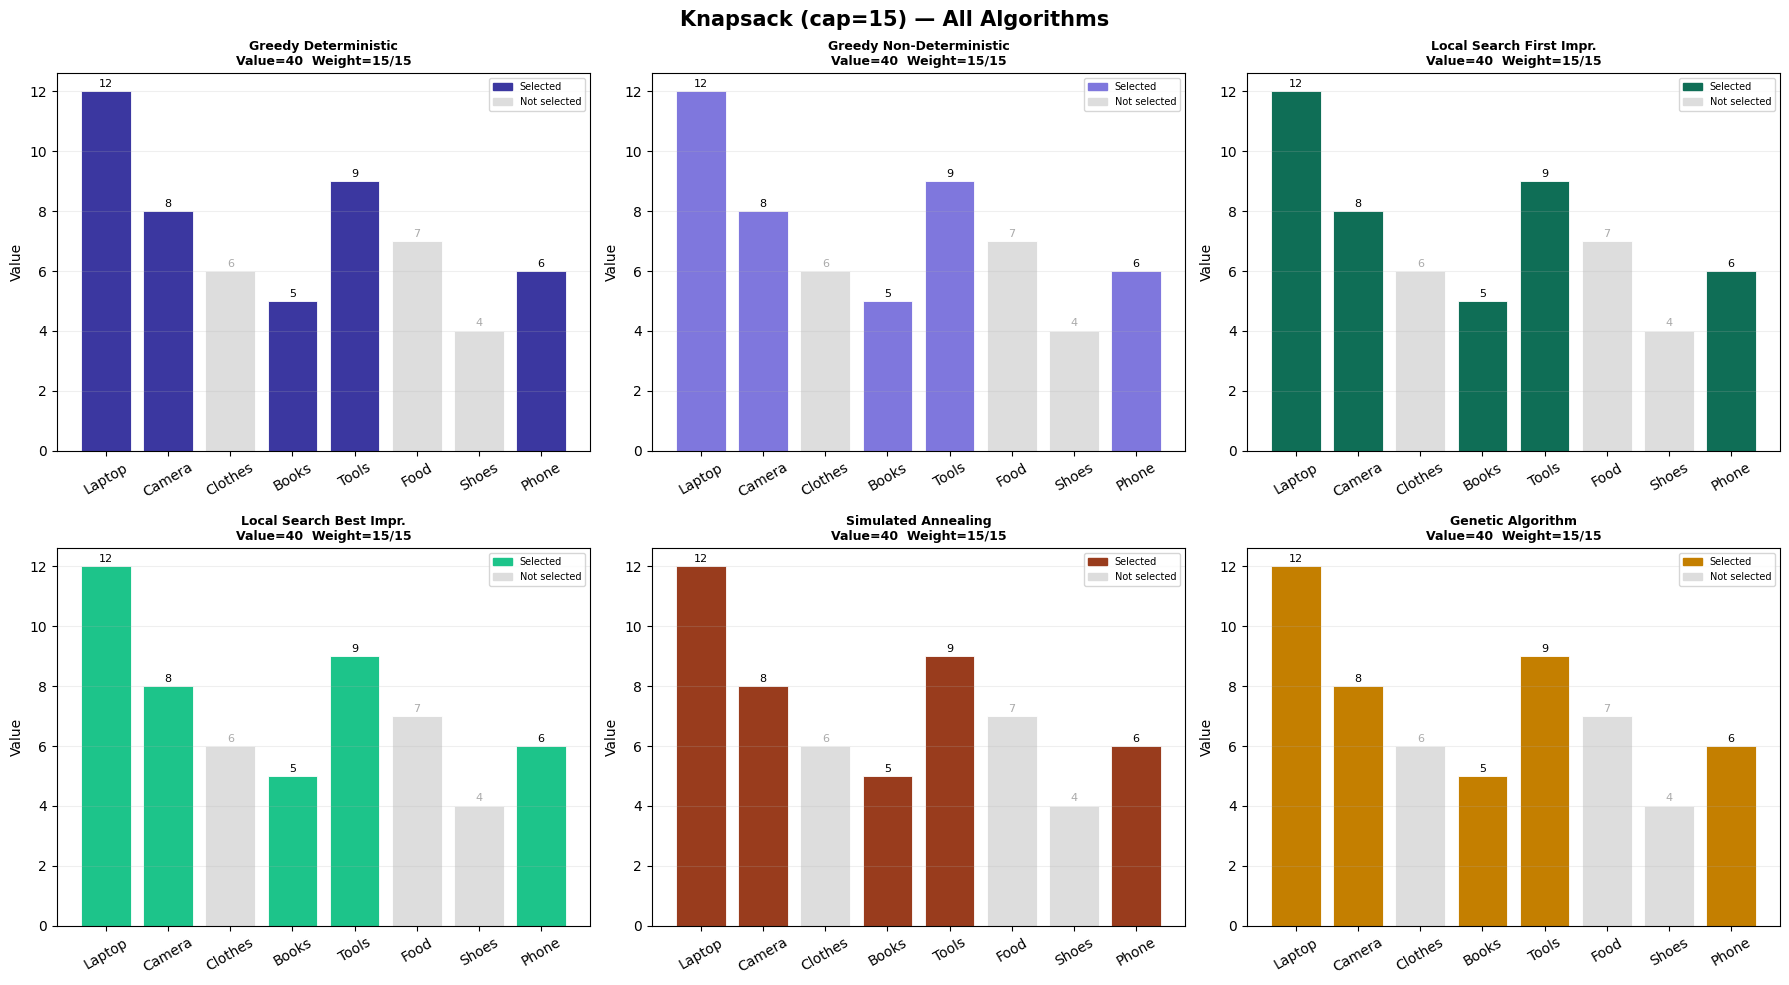

Saved: knapsack_all.png


In [ ]:
def draw_ks(ax, sel, title, color, val):
    inames = [it[0] for it in ITEMS]
    vals   = [it[2] for it in ITEMS]
    bclr   = [color if sel[i] else '#DDDDDD' for i in range(M)]
    bars   = ax.bar(inames, vals, color=bclr, edgecolor='white', linewidth=0.6)
    for bar, v, s in zip(bars, vals, sel):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                str(v), ha='center', fontsize=8, color='black' if s else '#AAAAAA')
    ax.legend(handles=[
        mpatches.Patch(color=color,     label='Selected'),
        mpatches.Patch(color='#DDDDDD', label='Not selected')
    ], fontsize=7)
    ax.set_title(f"{title}\nValue={val}  Weight={ks_weight(sel)}/{CAPACITY}",
                 fontsize=9, fontweight='bold')
    ax.set_ylabel("Value"); ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.2)

KS_ALL = [
    (ks_greedy_det,    "Greedy Deterministic",         '#3B37A0'),
    (ks_greedy_nondet, "Greedy Non-Deterministic",     '#7F77DD'),
    (ks_ls_first,      "Local Search First Impr.",     '#0F6E56'),
    (ks_ls_best,       "Local Search Best Impr.",      '#1DC48A'),
    (ks_sa,            "Simulated Annealing",           '#993C1D'),
    (ks_ga,            "Genetic Algorithm",             '#C47F00'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Knapsack (cap=15) — All Algorithms", fontsize=15, fontweight='bold')

for idx, (fn, title, color) in enumerate(KS_ALL):
    ax  = axes[idx//3][idx%3]
    res = fn()
    draw_ks(ax, res[0], title, color, res[1])

plt.tight_layout()
plt.savefig("knapsack_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: knapsack_all.png")


## Cell 14 — Genetic Algorithm Convergence Curves

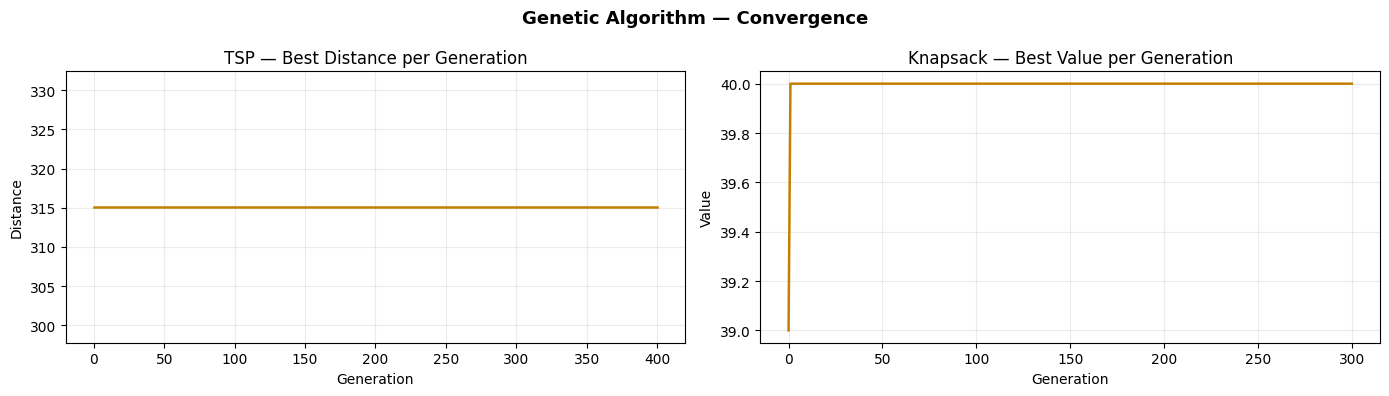

Saved: ga_convergence.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Genetic Algorithm — Convergence", fontsize=13, fontweight='bold')

ax1.plot(hist_tsp, color='#C47F00', linewidth=1.8)
ax1.set_title("TSP — Best Distance per Generation")
ax1.set_xlabel("Generation"); ax1.set_ylabel("Distance")
ax1.grid(True, alpha=0.25)

ax2.plot(hist_ks, color='#C47F00', linewidth=1.8)
ax2.set_title("Knapsack — Best Value per Generation")
ax2.set_xlabel("Generation"); ax2.set_ylabel("Value")
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("ga_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ga_convergence.png")


---
## Cell 15 — Final Comparison Table

In [ ]:
TSP_FNS = [
    ("Greedy — Deterministic",        tsp_greedy_det),
    ("Greedy — Non-Deterministic",    tsp_greedy_nondet),
    ("Local Search — First Impr.",    tsp_ls_first),
    ("Local Search — Best Impr.",     tsp_ls_best),
    ("Simulated Annealing",           tsp_sa),
    ("Genetic Algorithm",             tsp_ga),
]
KS_FNS = [
    ks_greedy_det, ks_greedy_nondet,
    ks_ls_first, ks_ls_best,
    ks_sa, ks_ga,
]

print("=" * 65)
print(f"  {'Algorithm':<35} {'TSP Dist':>10}  {'KS Value':>8}")
print("=" * 65)
for (name, tf), kf in zip(TSP_FNS, KS_FNS):
    td = tf()[1]; kv = kf()[1]
    print(f"  {name:<35} {td:>10.2f}  {kv:>8}")
print("=" * 65)
print()
print("  TSP  -> lower distance is better")
print("  KS   -> higher value is better")


  Algorithm                             TSP Dist  KS Value
  Greedy — Deterministic                  382.11        40
  Greedy — Non-Deterministic              315.09        39
  Local Search — First Impr.              306.01        40
  Local Search — Best Impr.               315.09        40
  Simulated Annealing                     318.16        40
  Genetic Algorithm                       315.09        40

  TSP  -> lower distance is better
  KS   -> higher value is better
